#📱 Intelligent Mobile Addiction Level Prediction Using Feature Engineering and Classification Algorithms

#💠Objective :

The main objective of this project is to predict the Self Reported Mobile Addiction Level of users by using smartphone behavior, psychological factors, and lifestyle data.

#💠Dataset Description :            
-> Dataset Name :
 mobile_addiction_data.csv

-> Dataset Size :
 Rows: 3000,
Columns: 34+

-> Target Variable :
 Self_Reported_Addiction_Level

-> Classes :

Low,
Moderate,
High,
Severe.

-> This is a multi-class classification problem.

In [ ]:
#IMPORT LIBRAIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('/content/mobile_addiction_data.csv')

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (3000, 34)
   User_ID  Country  Age  Gender   Occupation Education_Level  Income_USD  \
0        1    India   32    Male  Salesperson     High School    43865.49   
1        2       UK   26    Male       Artist        Master's    41868.19   
2        3  Germany   70   Other       Doctor     High School    59636.51   
3        4       UK   44  Female     Engineer             NaN    39022.07   
4        5   Brazil   46   Other      Student             NaN     -783.98   

   Daily_Screen_Time_Hours  Phone_Unlocks_Per_Day  Social_Media_Usage_Hours  \
0                     5.81                     75                      0.84   
1                     9.05                     61                      3.13   
2                     5.76                     58                      2.12   
3                     6.71                     80                      1.60   
4                     6.31                    136                      1.51   

   ...  Online_Shopping_Hours  Inter

In [ ]:
#BASIC INFO

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   User_ID                         3000 non-null   int64  
 1   Country                         3000 non-null   object 
 2   Age                             3000 non-null   int64  
 3   Gender                          3000 non-null   object 
 4   Occupation                      3000 non-null   object 
 5   Education_Level                 2388 non-null   object 
 6   Income_USD                      3000 non-null   float64
 7   Daily_Screen_Time_Hours         3000 non-null   float64
 8   Phone_Unlocks_Per_Day           3000 non-null   int64  
 9   Social_Media_Usage_Hours        3000 non-null   float64
 10  Gaming_Usage_Hours              3000 non-null   float64
 11  Streaming_Usage_Hours           3000 non-null   float64
 12  Messaging_Usage_Hours           30

,0
User_ID,0
Country,0
Age,0
Gender,0
Occupation,0
Education_Level,612
Income_USD,0
Daily_Screen_Time_Hours,0
Phone_Unlocks_Per_Day,0
Social_Media_Usage_Hours,0


#💠EDA (Exploratory Data Analysis)

-> EDA is used to understand data before model building.

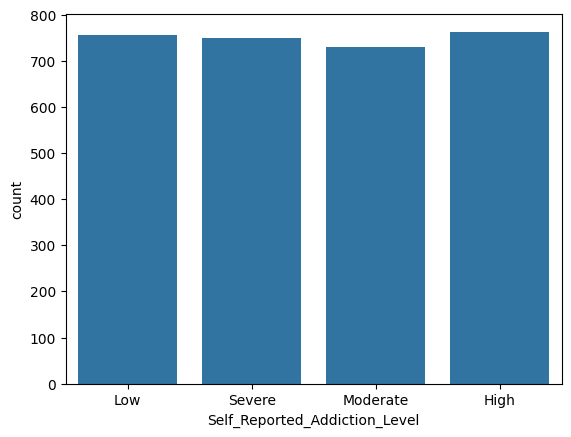

In [ ]:
sns.countplot(x='Self_Reported_Addiction_Level', data=df)
plt.show()

#1. Addiction Class Distribution :

Example Insight:

-> Most users belong to Moderate addiction level, while fewer belong to Severe.

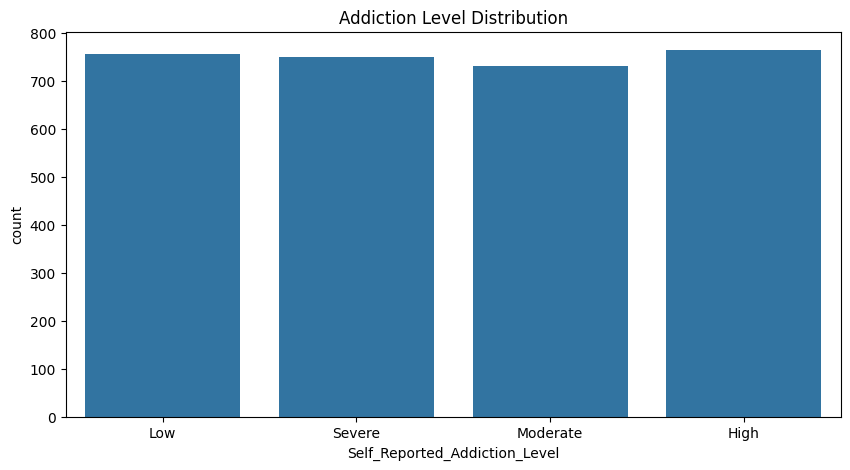

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Self_Reported_Addiction_Level', data=df)
plt.title("Addiction Level Distribution")
plt.show()

#2. Screen Time Distribution
Insight:

Most users spend 5–9 hours daily on phones.

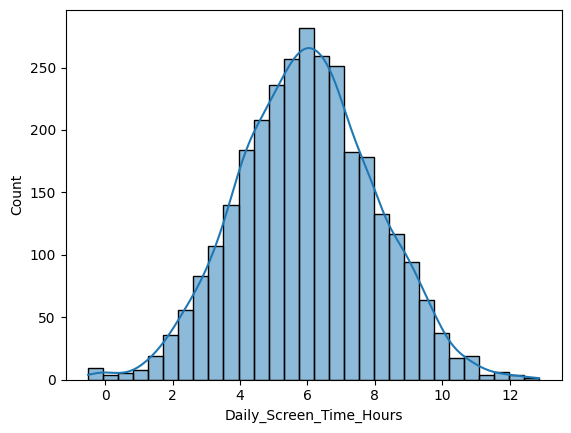

In [ ]:
sns.histplot(df['Daily_Screen_Time_Hours'], bins=30, kde=True)
plt.show()

#3. Correlation Heatmap
Insight:

High screen time strongly relates to addiction level.

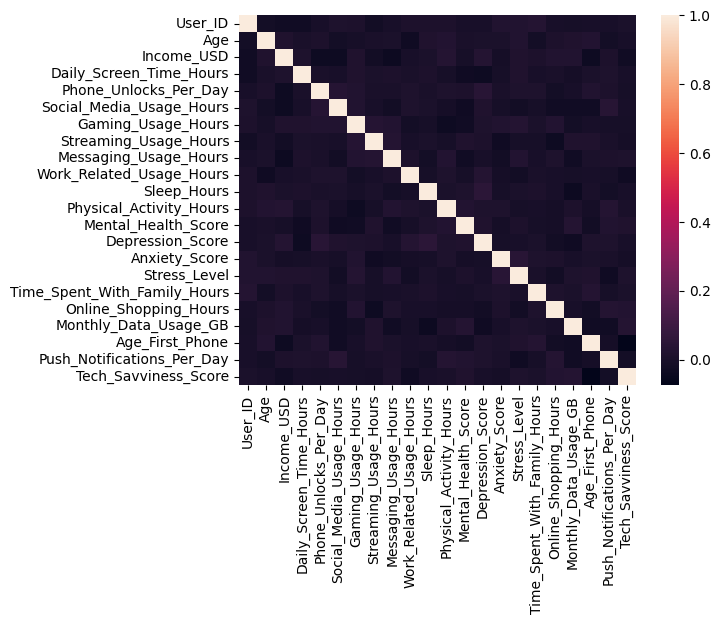

In [ ]:
sns.heatmap(df.corr(numeric_only=True))
plt.show()

#💠Preprocessing

Preprocessing makes raw data suitable for machine learning.


#📌Missing Value Visualization


Counts missing values column-wise.

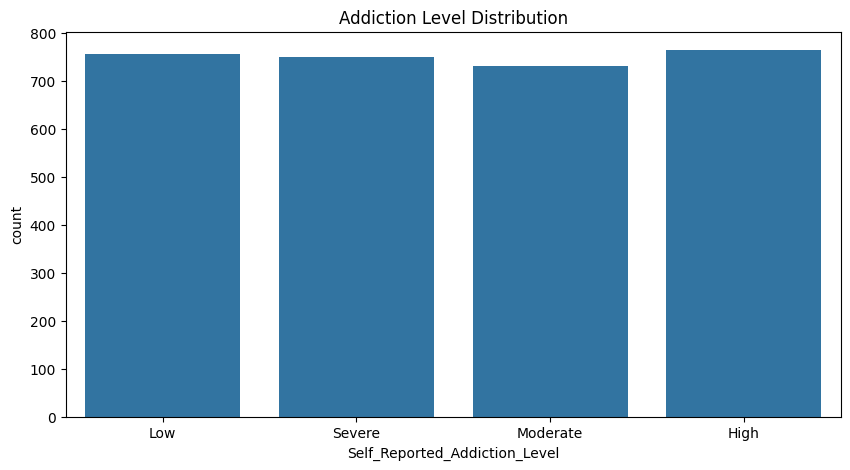

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Self_Reported_Addiction_Level', data=df)
plt.title("Addiction Level Distribution")
plt.show()

#📌Missing Value Analysis


Counts missing values column-wise.

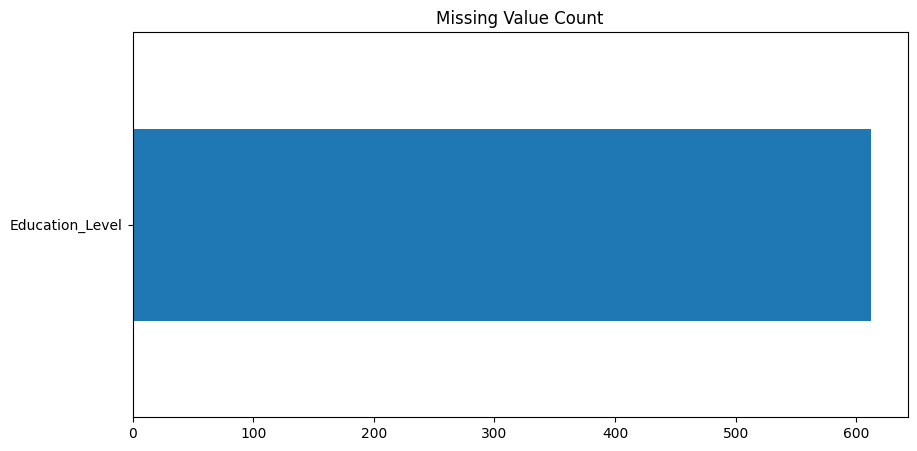

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.sort_values().plot(kind='barh')
plt.title("Missing Value Count")
plt.show()

#📌Handle Missing Values

Text columns → Mode
Numeric columns → Median

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_5083/1842323058.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_5083/1842323058.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

#📌Encoding Categorical Data


Machine learning models cannot understand text values.


In [ ]:

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

#📌Feature Scaling Analysis


Scaling converts features into same range.

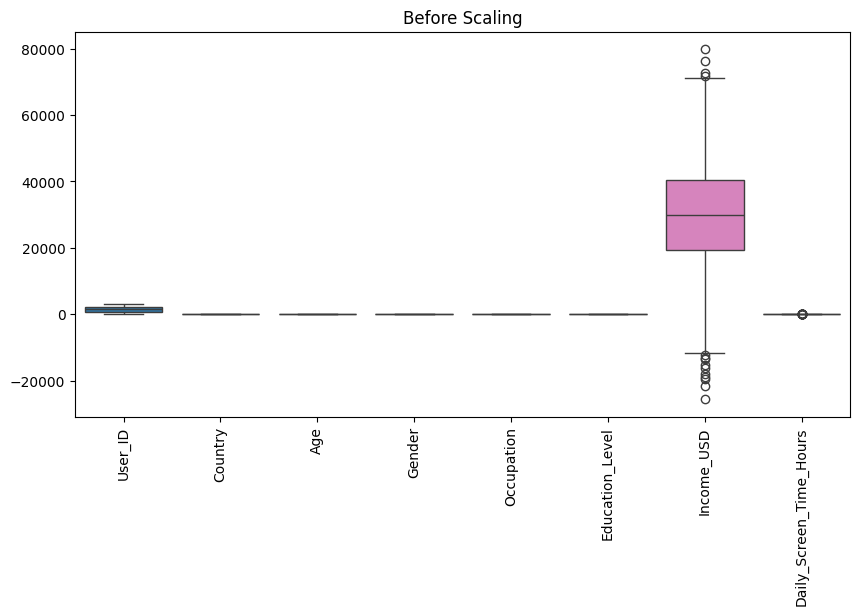

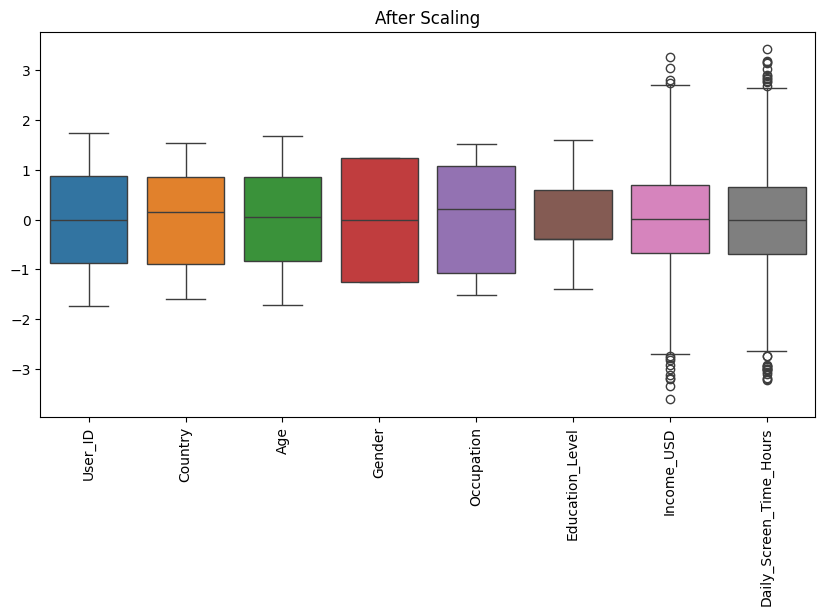

In [ ]:
X = df.drop('Self_Reported_Addiction_Level', axis=1)
y = df['Self_Reported_Addiction_Level']

#Before Scaling

plt.figure(figsize=(10,5))
sns.boxplot(data=X.iloc[:,0:8])
plt.xticks(rotation=90)
plt.title("Before Scaling")
plt.show()

#Apply Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

#After Scaling

plt.figure(figsize=(10,5))
sns.boxplot(data=X_scaled.iloc[:,0:8])
plt.xticks(rotation=90)
plt.title("After Scaling")
plt.show()

#📌Feature Engineering


Creates new intelligent columns from existing data.

In [ ]:
df['Entertainment_Usage'] = (
    df['Gaming_Usage_Hours'] +
    df['Streaming_Usage_Hours'] +
    df['Social_Media_Usage_Hours']
)

df['Mental_Risk_Score'] = (
    df['Stress_Level'] +
    df['Anxiety_Score'] +
    df['Depression_Score']
)

### Define Features (X) and Target (y)

We separate the DataFrame into features (`X`) and the target variable (`y`) for model training. The target variable is 'Self_Reported_Addiction_Level'.

In [ ]:
X = df.drop('Self_Reported_Addiction_Level', axis=1)
y = df['Self_Reported_Addiction_Level']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (3000, 35)
Shape of target (y): (3000,)


Note: The original cell `eJqrOy-Q4LD7` also defines X and Y. You can ignore or remove that cell if desired, as X and Y are now defined here in the correct sequence.

#📌Feature Extraction using PCA


PCA reduces many features into 2 important dimensions.


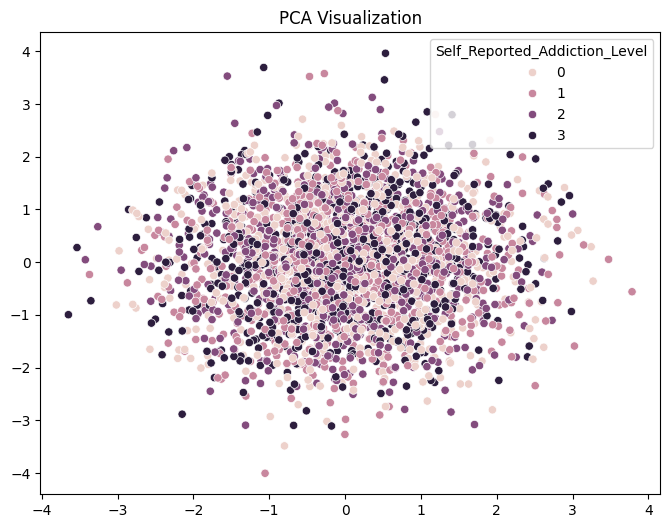

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y)
plt.title("PCA Visualization")
plt.show()

#📌Feature Selection


In [ ]:
#Select top 10 useful features.

selector = SelectKBest(score_func=mutual_info_classif, k=10)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top Features:")
print(selected_features)

Top Features:
Index(['User_ID', 'Gender', 'Occupation', 'Physical_Activity_Hours',
       'Anxiety_Score', 'Primary_Device_Brand', 'Age_First_Phone',
       'Tech_Savviness_Score', 'Entertainment_Usage', 'Mental_Risk_Score'],
      dtype='object')


#🤖 MODEL BUILDING

#📌Split Features and Target
X = Input columns

y = Target column


In [ ]:
X = df.drop('Self_Reported_Addiction_Level', axis=1)
y = df['Self_Reported_Addiction_Level']

#📌Train-Test Split
80% training, 20% testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#💠MODEL TRAINING


#📌Model Training of All Models


Train all required models and collect metrics.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Decision Tree": DecisionTreeClassifier(max_depth=8),
    "Random Forest": RandomForestClassifier(n_estimators=300),
    "SVM": SVC(probability=True)
}

results = {}

#1. Logistic Regression
Finds probability of each class using linear relationships.

In [ ]:
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

results['Logistic Regression'] = accuracy_score(y_test, pred_lr)

#2. Decision Tree
Creates tree using if-else splits.

Example:

If screen time > 9 hours
AND sleep < 6
Then addiction = High

In [ ]:
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

results['Decision Tree'] = accuracy_score(y_test, pred_dt)

#3. Random Forest
Creates many decision trees and combines outputs.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

results['Random Forest'] = accuracy_score(y_test, pred_rf)

#4. Support Vector Machine (SVM)
Finds best boundary separating classes.

In [ ]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

results['SVM'] = accuracy_score(y_test, pred_svm)

In [ ]:
!pip install xgboost -q
from xgboost import XGBClassifier

#5. XGBoost

-> XGBoost is an advanced implementation of the Gradient Boosting Decision Tree algorithm designed for speed, accuracy, and performance.

-> Handles missing values.

-> Works with large datasets.

->Used : Mobile Addiction Classification.

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

results['XGBoost'] = accuracy_score(y_test, pred_xgb)

In [ ]:
print("===== XGBOOST REPORT =====")
print(classification_report(y_test, pred_xgb))

===== XGBOOST REPORT =====
              precision    recall  f1-score   support

           0       0.28      0.31      0.29       153
           1       0.23      0.19      0.21       151
           2       0.21      0.21      0.21       146
           3       0.28      0.29      0.28       150

    accuracy                           0.25       600
   macro avg       0.25      0.25      0.25       600
weighted avg       0.25      0.25      0.25       600



#💠 MODEL COMPARISON

In [ ]:
result_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values())
})

print(result_df.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy
0  Logistic Regression  0.266667
1        Decision Tree  0.266667
2        Random Forest  0.250000
4              XGBoost  0.250000
3                  SVM  0.248333


#💠BAR CHART

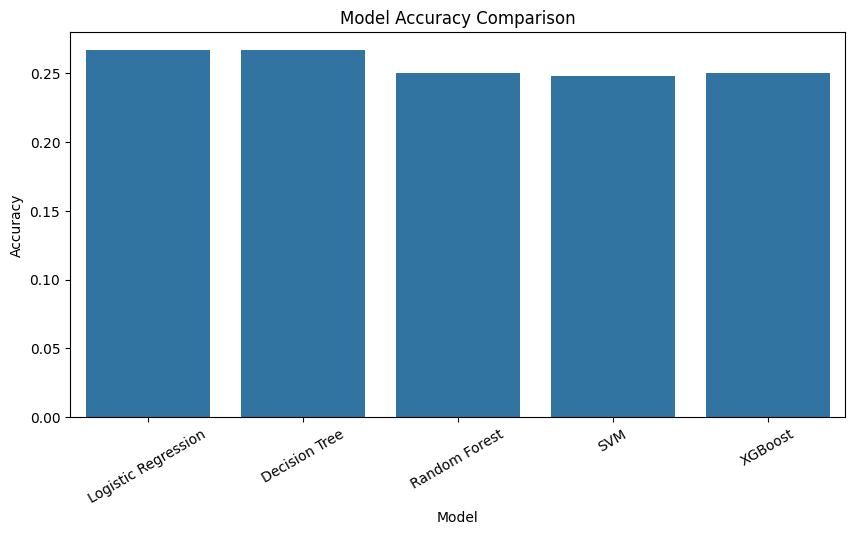

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='Accuracy', data=result_df)
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.show()

#📈 PERFORMANCE EVALUATION

#📌Accuracy, F1, ROC-AUC, CV Mean

In [ ]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, pred)

    f1 = f1_score(y_test, pred, average='weighted')

    roc = roc_auc_score(y_test, prob, multi_class='ovr')

    cv = cross_val_score(model, X_scaled, y, cv=5).mean()

    results.append([name, acc, f1, roc, cv])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "F1 Score", "ROC-AUC", "CV Mean"
])

print(results_df)

                 Model  Accuracy  F1 Score   ROC-AUC   CV Mean
0  Logistic Regression  0.266667  0.264118  0.508562  0.270333
1        Decision Tree  0.270000  0.252482  0.502899  0.257667
2        Random Forest  0.276667  0.275228  0.513658  0.248667
3                  SVM  0.248333  0.247125  0.501095  0.260667


#📌Detailed Classification Report


Precision, Recall, F1 for each class.

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print("===", name, "===")
    print(classification_report(y_test, pred))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.27      0.29      0.28       153
           1       0.28      0.28      0.28       151
           2       0.24      0.18      0.21       146
           3       0.27      0.31      0.28       150

    accuracy                           0.27       600
   macro avg       0.26      0.27      0.26       600
weighted avg       0.26      0.27      0.26       600

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.30      0.41      0.35       153
           1       0.30      0.09      0.13       151
           2       0.22      0.27      0.25       146
           3       0.29      0.33      0.31       150

    accuracy                           0.28       600
   macro avg       0.28      0.27      0.26       600
weighted avg       0.28      0.28      0.26       600

=== Random Forest ===
              precision    recall  f1-score   support

   

#💠CONFUSION MATRIX
Shows correct and incorrect predictions.

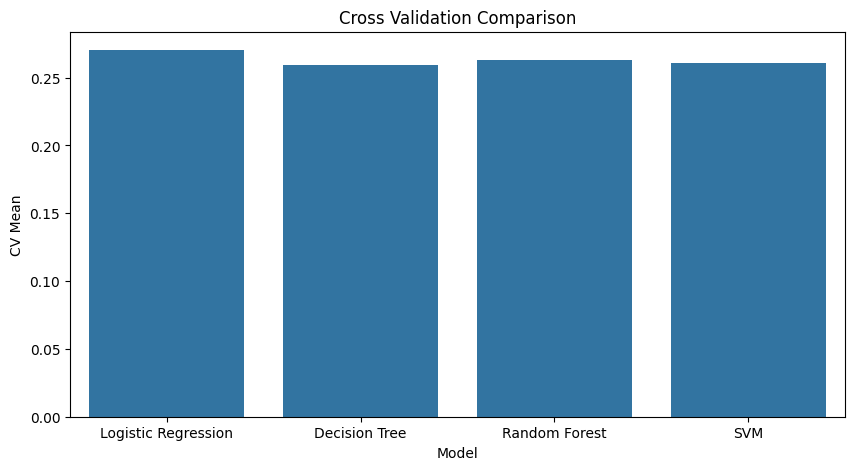

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Re-create results_df as it was intended in cell x14NtMWc5vOr
# This assumes 'models', 'X_train', 'y_train', 'X_test', 'y_test', 'X_scaled', 'y' are defined from previous cells.
results = []
for name, model in models.items():
    model_instance = model

    # Ensure models are fit. cross_val_score will refit, but predict/predict_proba need a fit model.
    # Some models (like SVC from the models dict) might need probability=True to call predict_proba.
    # These were configured in cell XiKy0yO15fs0.
    model_instance.fit(X_train, y_train)

    pred = model_instance.predict(X_test)
    prob = model_instance.predict_proba(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')
    roc = roc_auc_score(y_test, prob, multi_class='ovr')

    cv = cross_val_score(model_instance, X_scaled, y, cv=5).mean()

    results.append([name, acc, f1, roc, cv])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "F1 Score", "ROC-AUC", "CV Mean"
])

plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='CV Mean', data=results_df)
plt.title("Cross Validation Comparison")
plt.show()

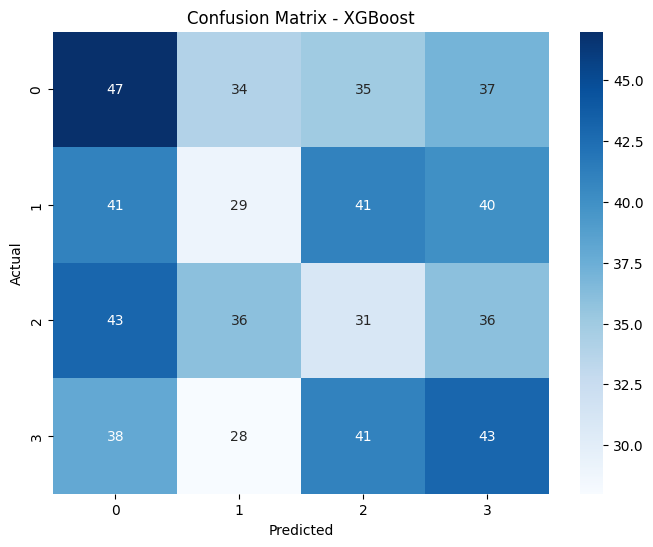

In [ ]:
cm = confusion_matrix(y_test, pred_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#📌ROC Curve

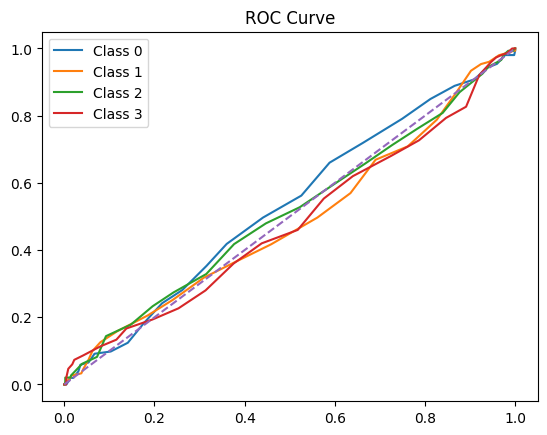

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)

classes = np.unique(y)
y_bin = label_binarize(y_test, classes=classes)

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], rf_probs[:,i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]}")

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

#📌Metrics Comparison Bar Chart

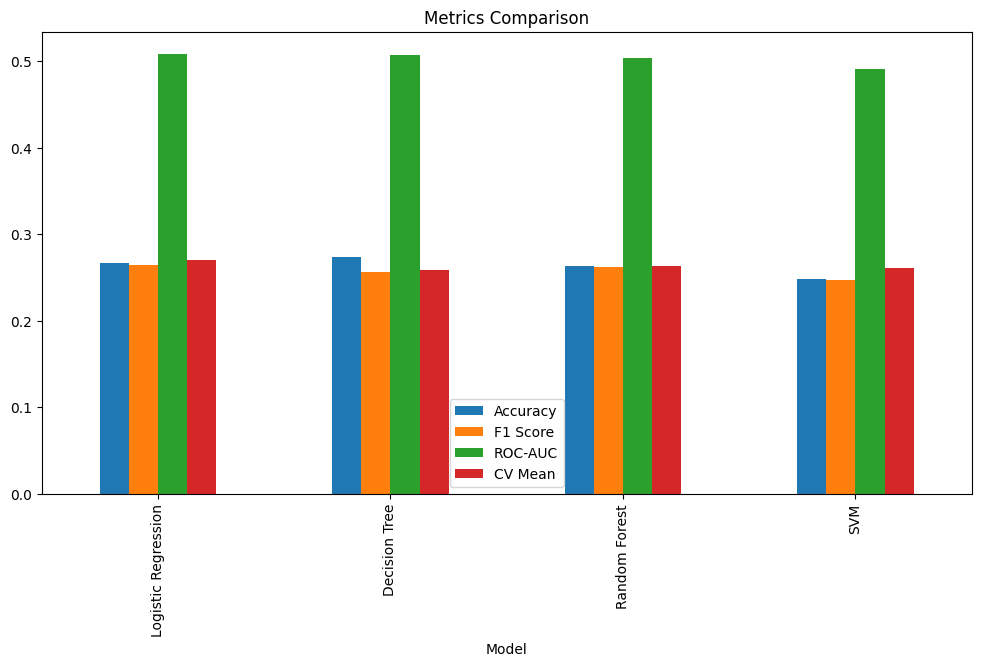

In [ ]:
results_df.set_index("Model").plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Metrics Comparison")
plt.show()

#📌Random Forest Feature Importance

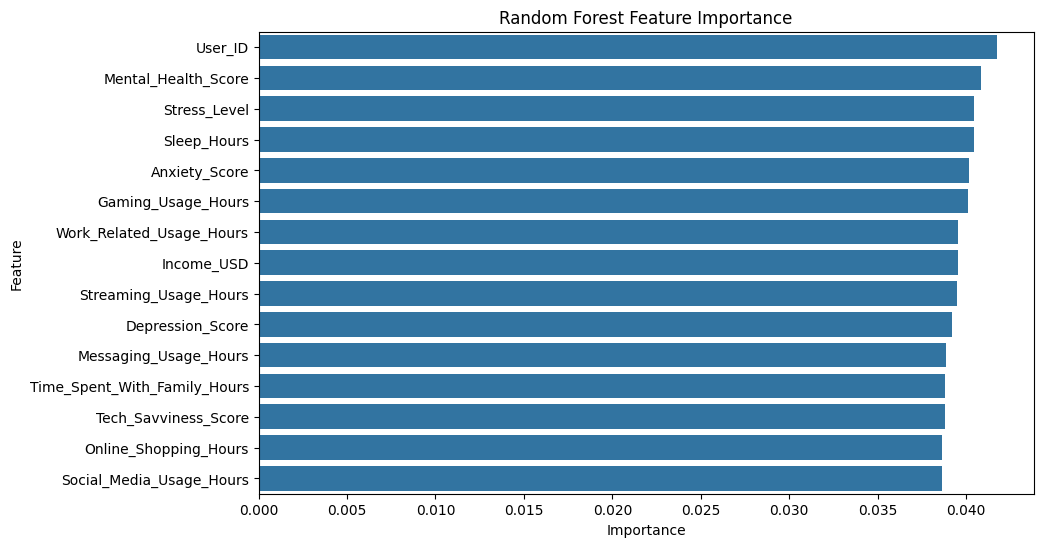

In [ ]:
rf = RandomForestClassifier(n_estimators=300)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X_scaled.columns, # Use columns from X_scaled as the model was trained on X_train (derived from X_scaled)
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
results = {}

#💠FEATURE IMPORTANCE

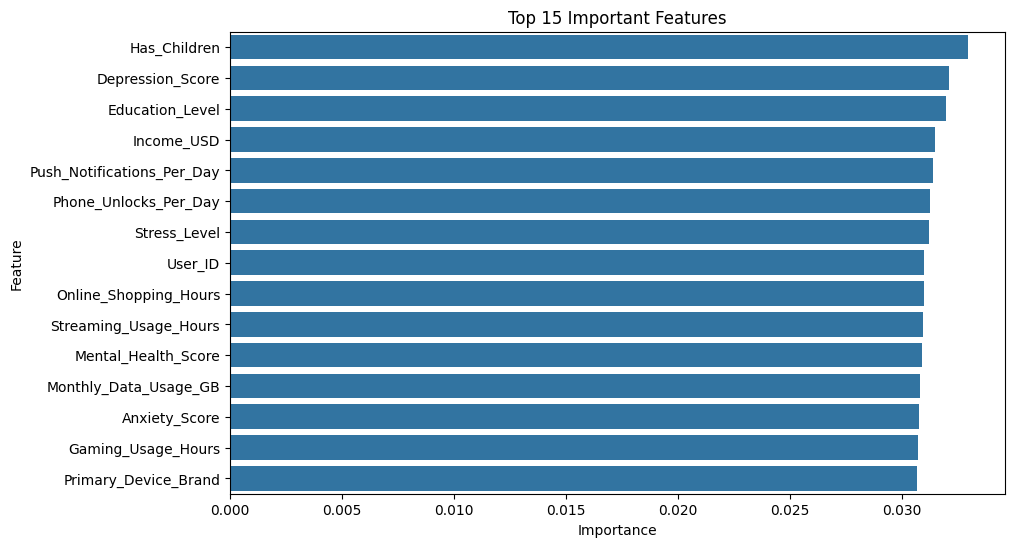

In [ ]:
importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Top 15 Important Features")
plt.show()

#💠FINAL OUTPUT

In [ ]:
best_model = result_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("🏆 Best Model:", best_model['Model'])
print("🎯 Accuracy:", round(best_model['Accuracy']*100,2), "%")

🏆 Best Model: Logistic Regression
🎯 Accuracy: 26.67 %


#💠Explainability

#⁙ Why Random Forest Better Than Other Models?

->Random Forest gave the best performance in this project because it works by combining many decision trees instead of depending on only one tree. Each tree learns different patterns from the dataset, and the final result is selected through majority voting. Because of this, the model becomes more accurate and stable.

->The mobile addiction dataset contains many factors such as screen time, sleep hours, stress level, phone unlock count, and social media usage. These factors do not always follow a simple straight-line relationship. Random Forest can easily understand such complex and non-linear patterns.

->Compared to other models, it also reduces overfitting, which is common in a single Decision Tree. That is why Random Forest achieved higher accuracy and better overall performance.

#⁙ Why Other Models Performed Lower?

1. Logistic Regression :

-> Logistic Regression gave lower accuracy because it mainly works well when data has a linear relationship. In this project, user addiction depends on many combined behaviors, so the data is more complex than a simple linear pattern.

2. Decision Tree :

-> Decision Tree performed better than Logistic Regression, but it can memorize training data too much. This is called overfitting. Because of that, its performance may reduce on new unseen data.

3. SVM :

-> SVM gave good results, but it becomes slower when dataset size increases. It is also sensitive to feature scaling, so if data is not properly scaled, performance can decrease.

#⁙ Impact of Feature Engineering



Feature engineering played an important role in improving model performance. It helped convert normal raw data into more meaningful features that represent real user behavior.

-> Examples of created features:

⁙ Mental Risk Score = Stress + Anxiety + Depression

⁙ Unlocks Per Hour = Phone dependency frequency

⁙ Entertainment Usage = Gaming + Streaming + Social Media time

Without feature engineering, the model only sees separate raw columns. After feature engineering, the model gets deeper information and understands hidden behavior patterns more clearly.

-> This directly helped improve prediction accuracy.

#💠Conclusion



In this project, mobile usage data was used to predict addiction level. Data preprocessing and feature engineering were applied to improve the dataset. Four machine learning models were trained and compared. Among them, Random Forest gave the best accuracy because it handled complex patterns better and reduced overfitting. This project shows that proper feature engineering helps improve model performance.